# Evaluating a trained KIND model

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot

### Load a trained KIND model

In [2]:
# --! load a trained KIND model --!

model = torch.load('../../models/baselines/tesla_kind.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=640, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var): Linear(in_features=8, out_features=8, bias=False)
    (pre_mean_dec): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=Tru

### Analyze the stationary part of a KIND model

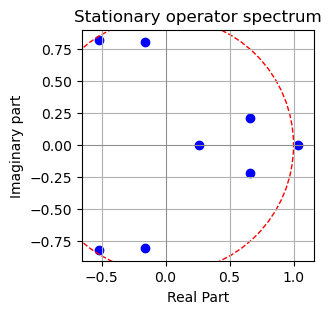

tensor([-0.5232+0.8211j, -0.5232-0.8211j, -0.1602+0.8046j, -0.1602-0.8046j,
         1.0312+0.0000j,  0.6591+0.2143j,  0.6591-0.2143j,  0.2615+0.0000j])


In [3]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

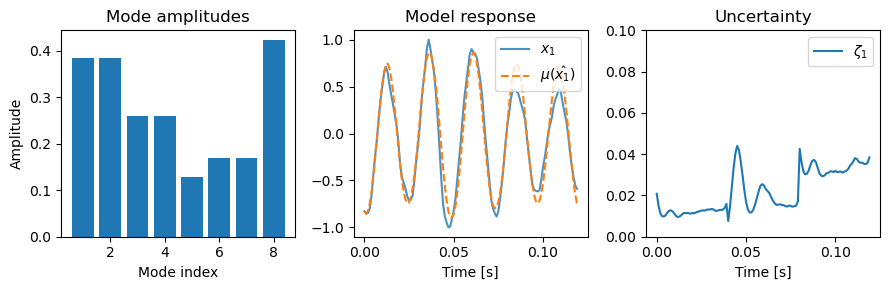

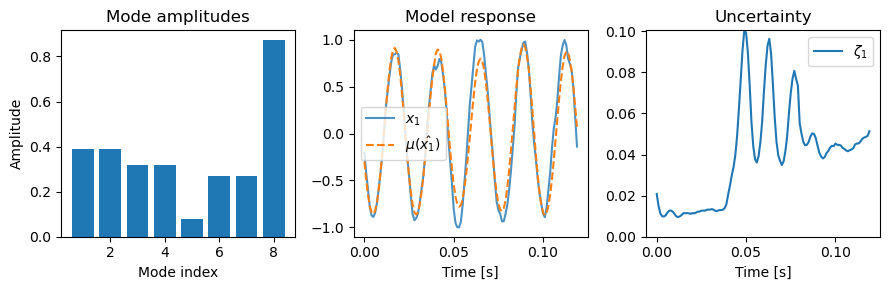

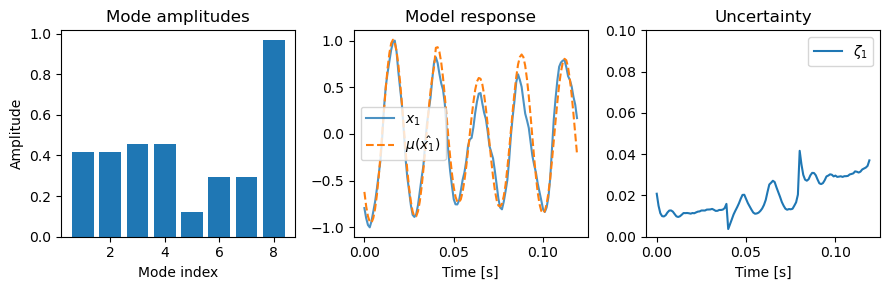

In [4]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/tesla_train_stat'
timeseries_nsample = 120

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### Evaluate KIND performance on test data

In [5]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/tesla_test'
timeseries_nsample = 250_000

mse_stat, mse_trans, mse_blend = utils_plot.plot_mse(model, datadir, timeseries_nsample)


inf >> forecasting results:

         mse      index      value
 -----------   --------   --------
  best blend     213722      0.001
 worst blend      21223      1.384
   avg blend         na      0.085
                                  
   best stat     213723      0.001
  worst stat      84473      2.380
    avg stat         na      0.221
                                  
  best trans     192430      0.001
 worst trans      21223      1.592
   avg trans         na      0.087

inf >> mean alpha is 0.27



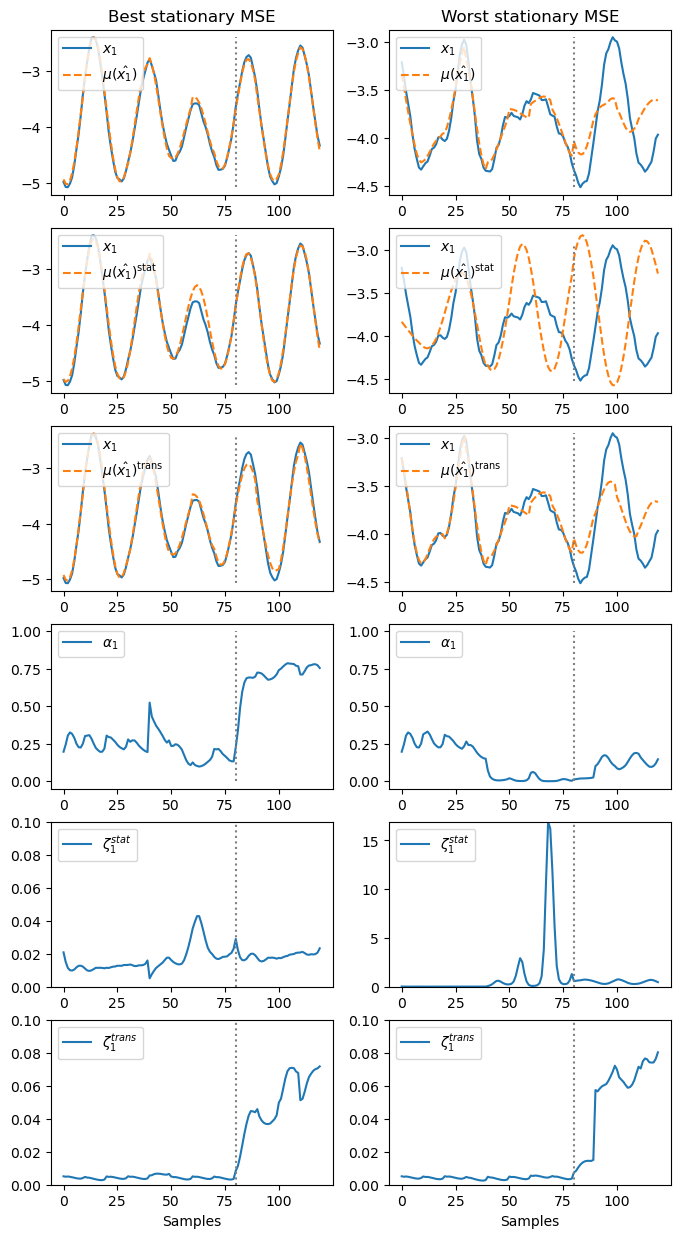

In [6]:
# --! plot the best and worst stationary performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_stat, mse_type='stationary',
    datasaved=True, savedir='../../savedata/baselines/tesla')

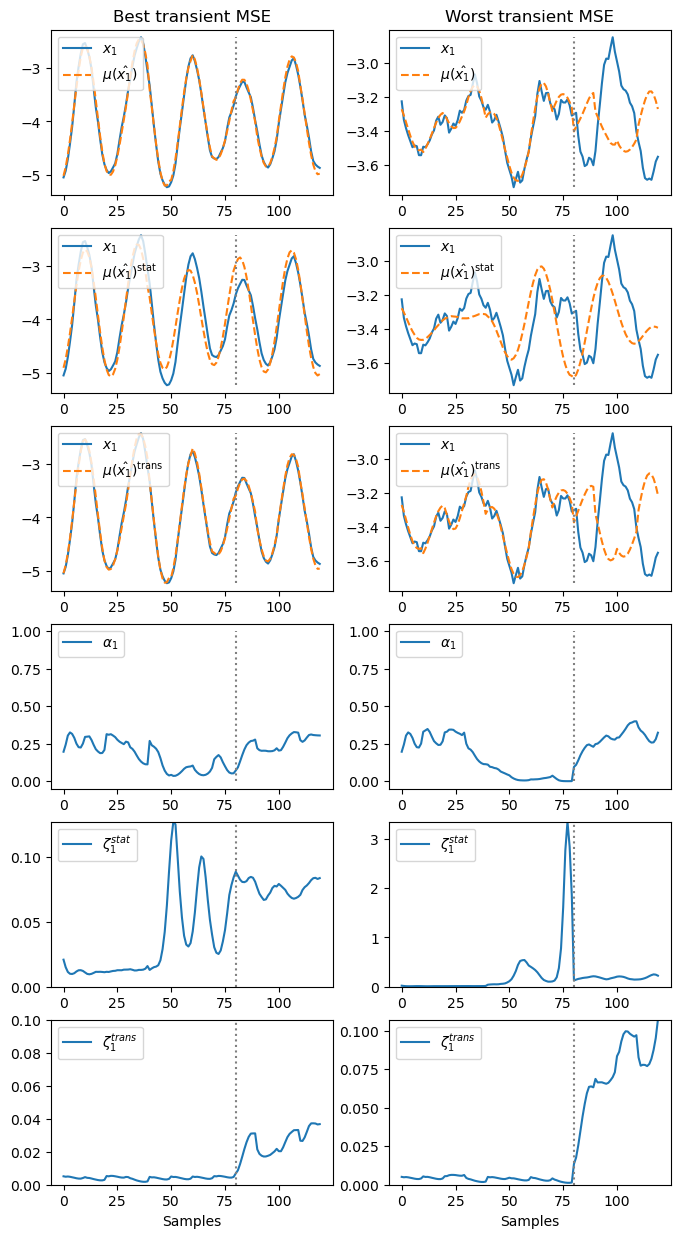

In [7]:
# --! plot the best and worst transient performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_trans, mse_type='transient',
    datasaved=True, savedir='../../savedata/baselines/tesla')

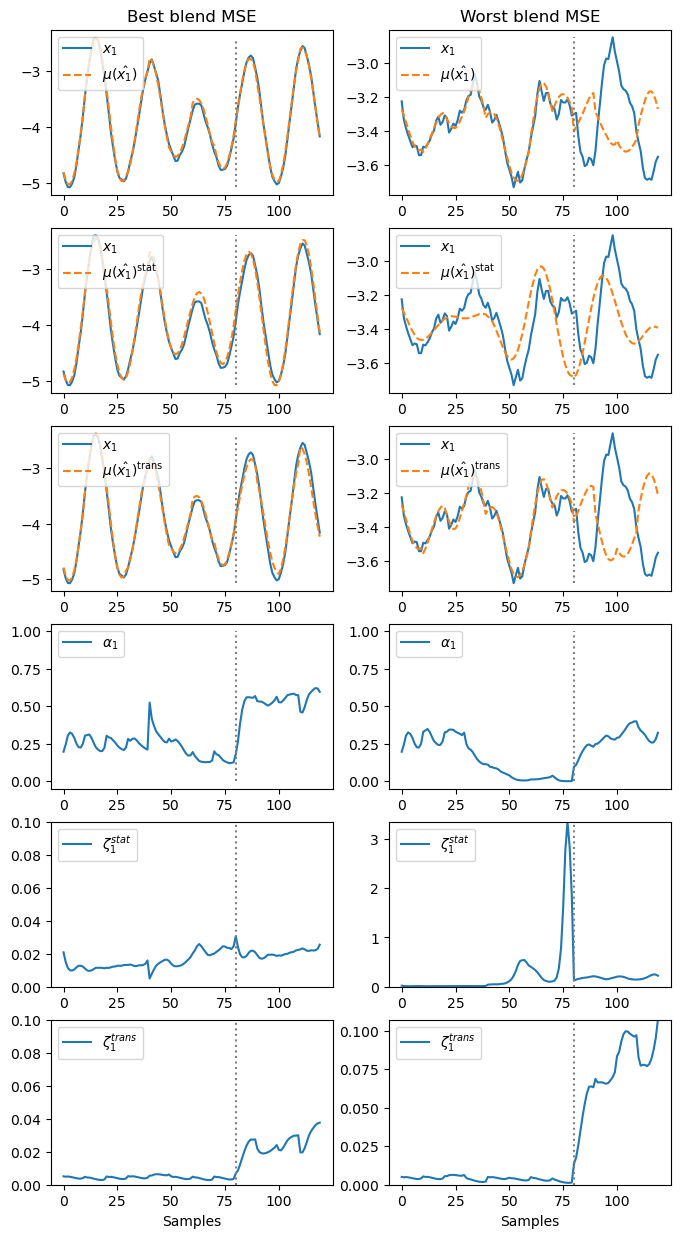

In [8]:
# --! plot the best and worst blending performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    datasaved=True, savedir='../../savedata/baselines/tesla')

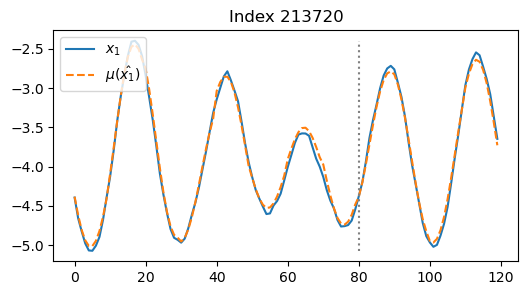

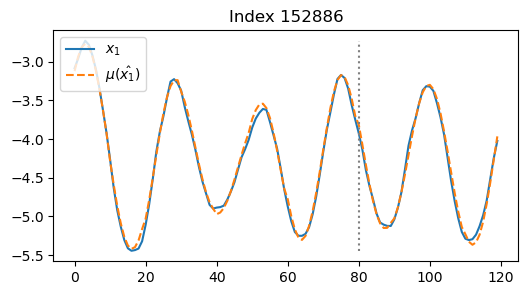

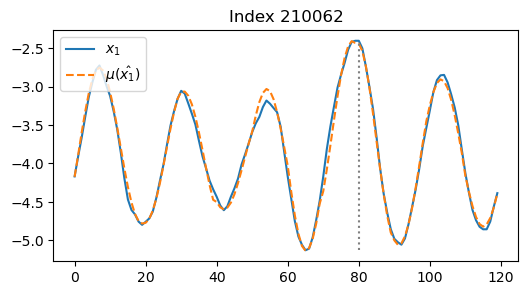

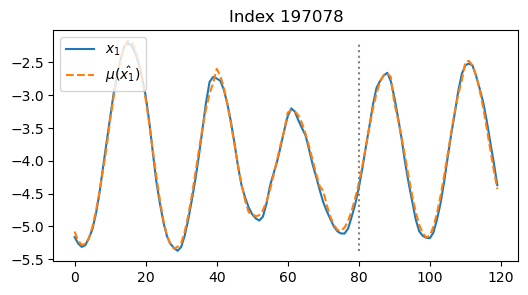

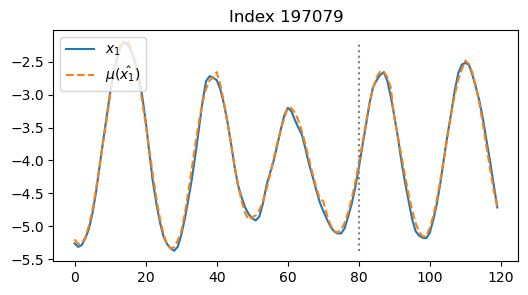

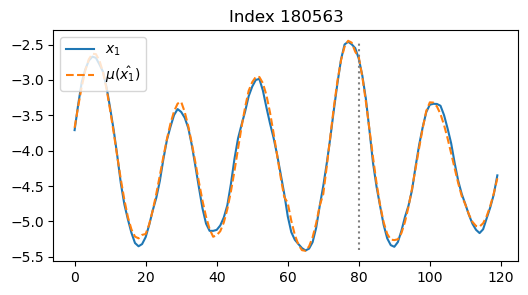

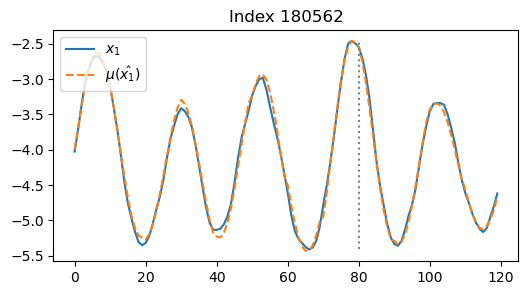

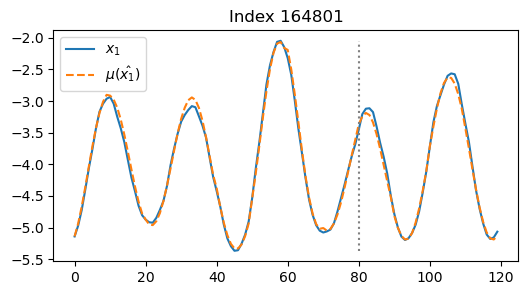

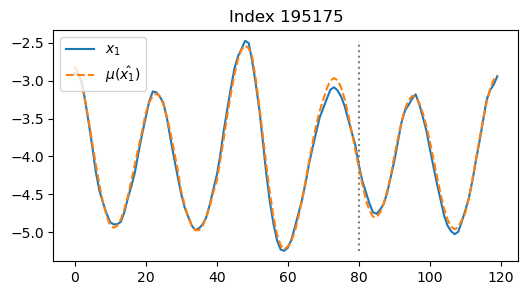

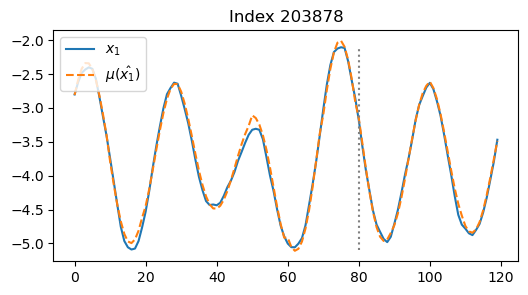

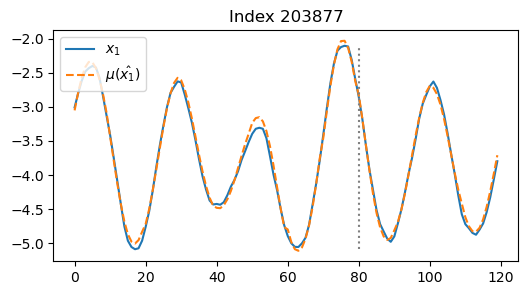

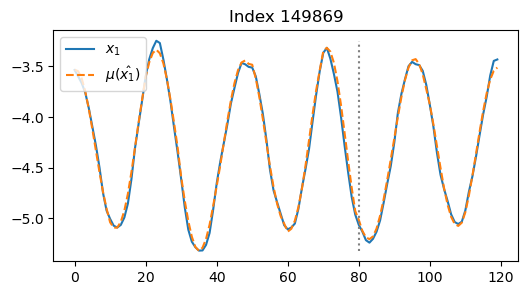

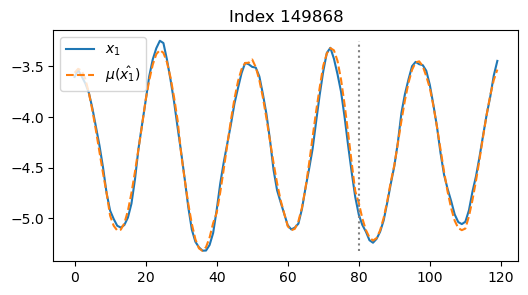

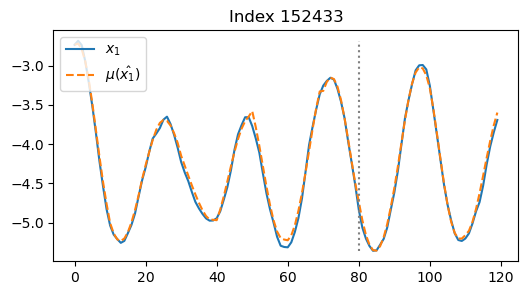

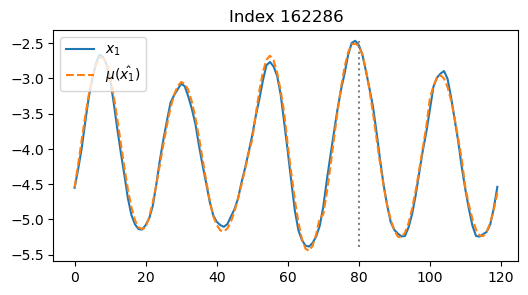

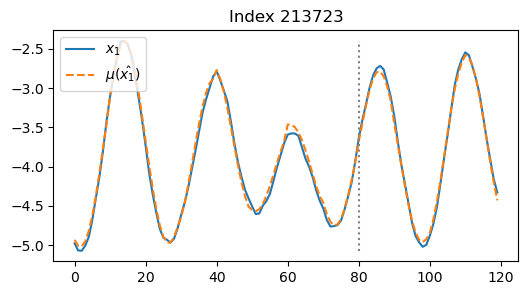

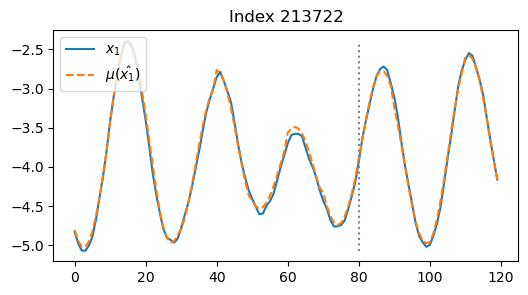

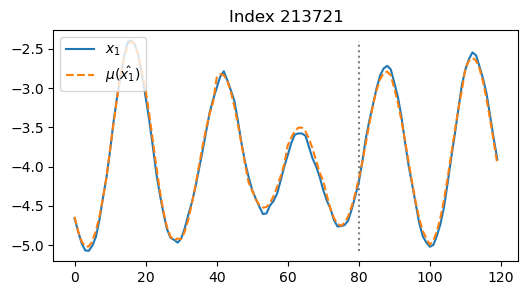

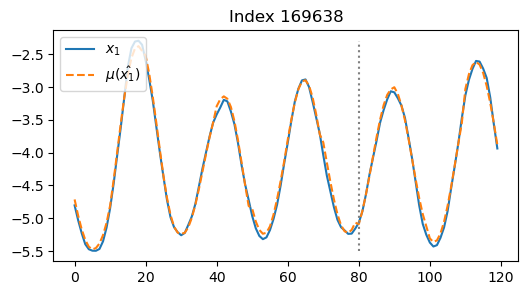

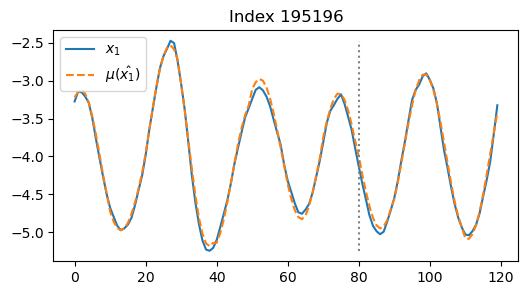

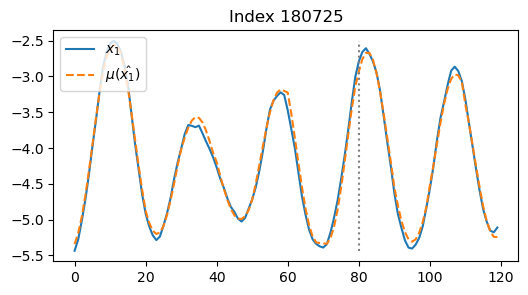

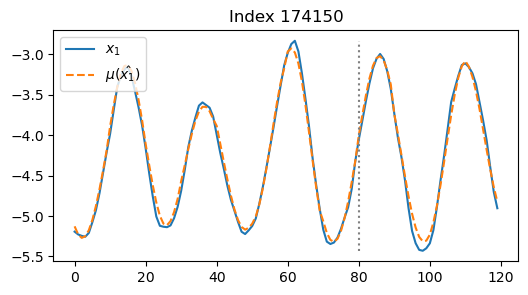

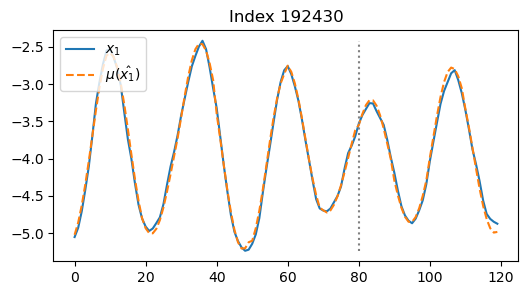

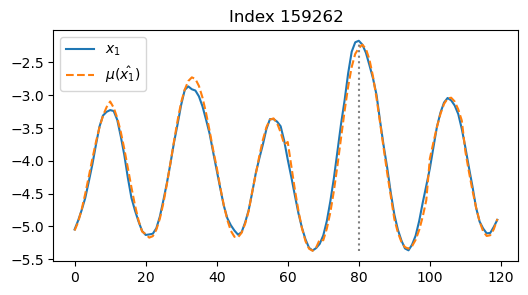

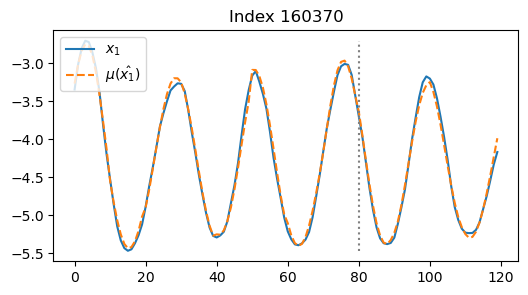

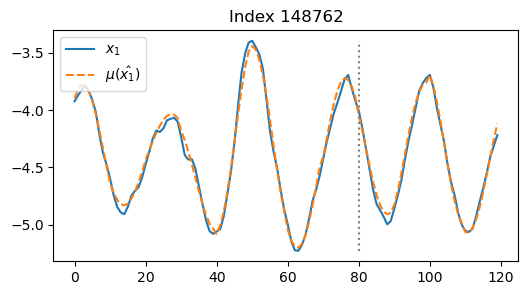

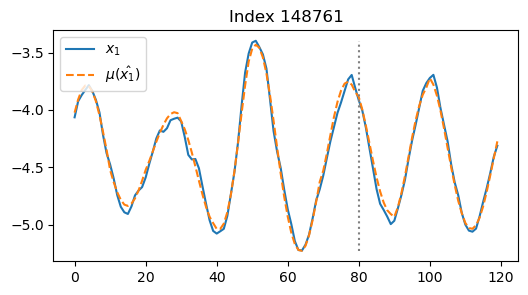

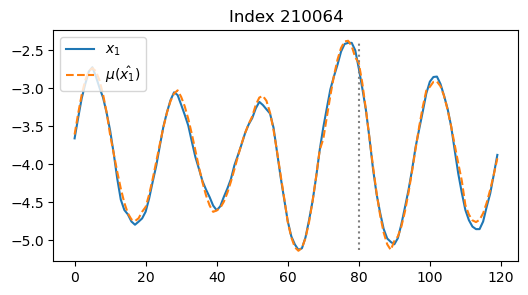

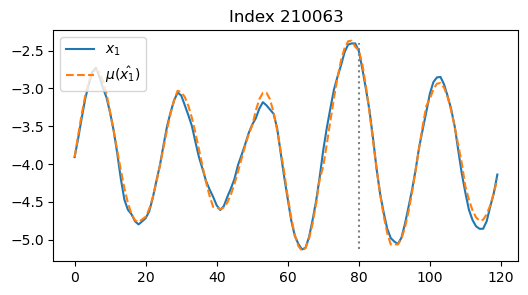

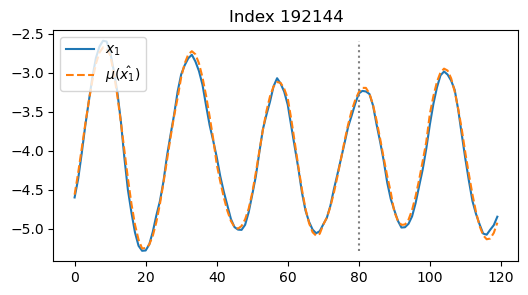

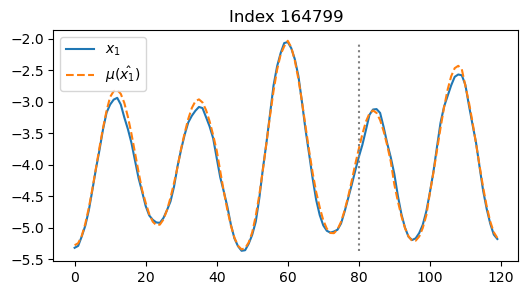

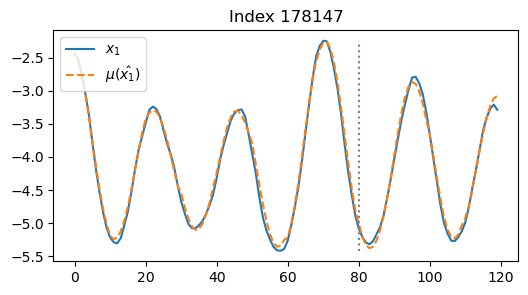

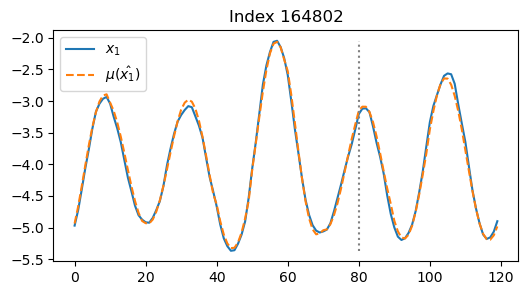

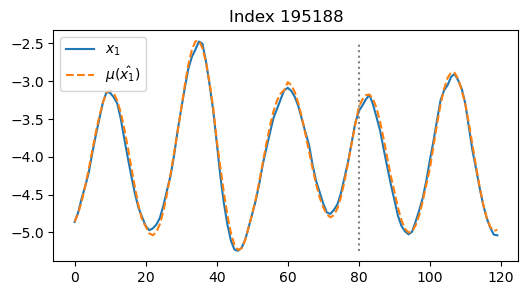

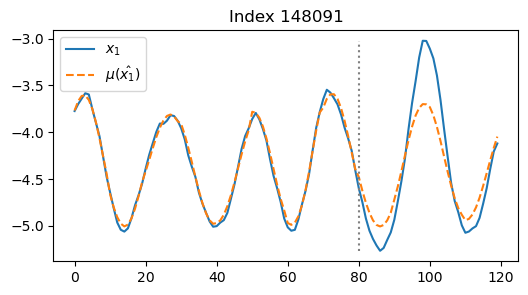

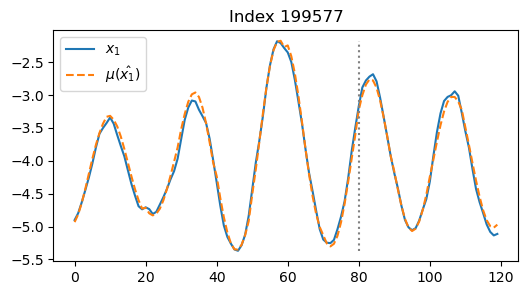

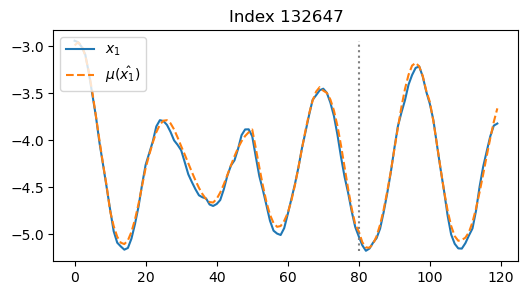

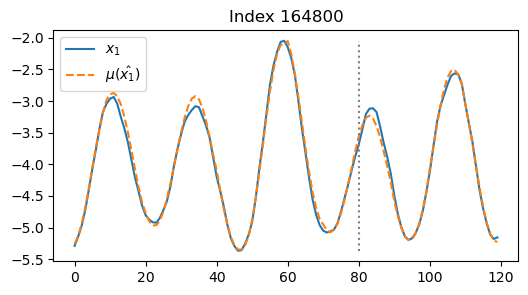

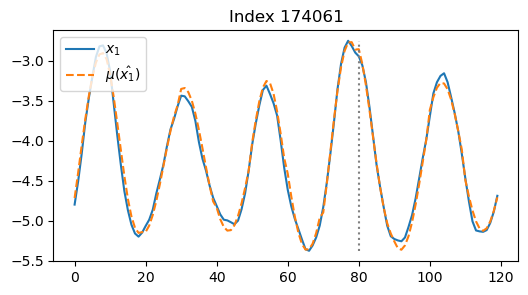

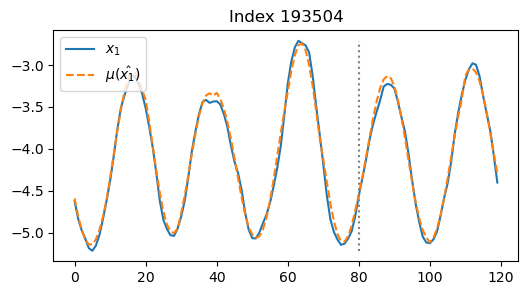

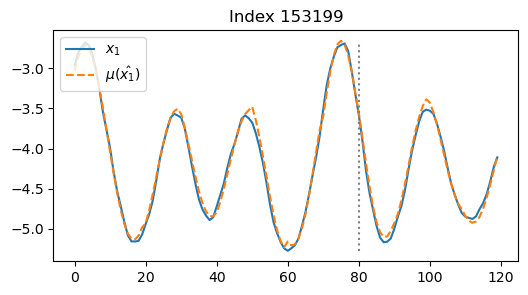

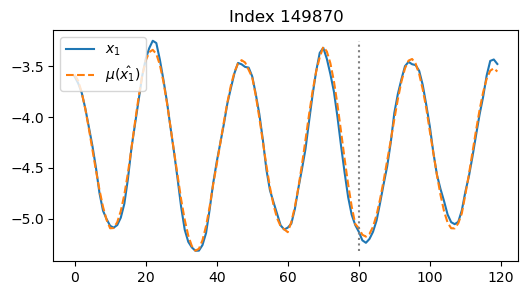

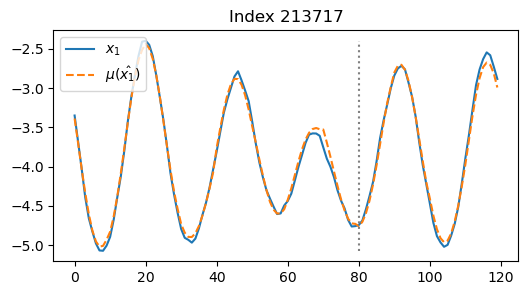

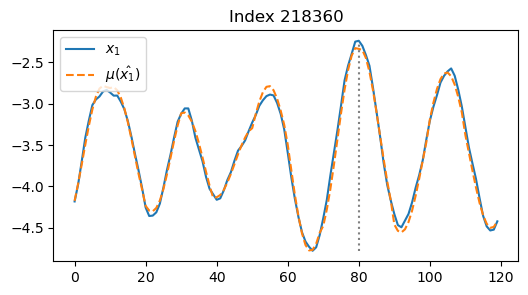

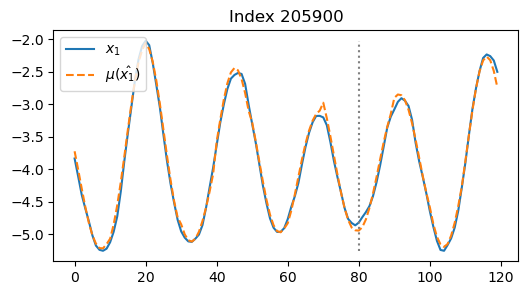

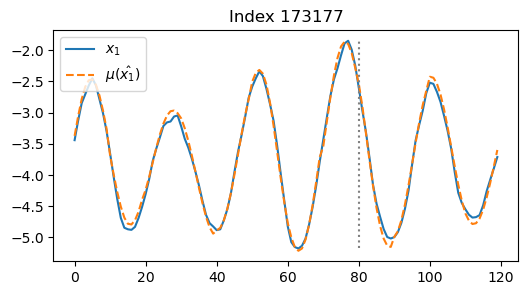

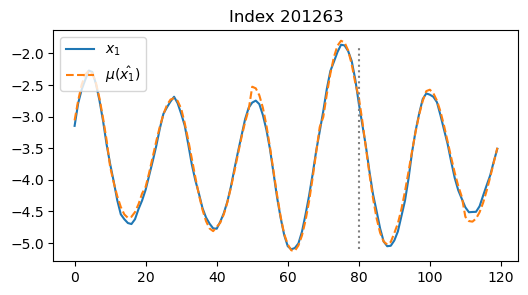

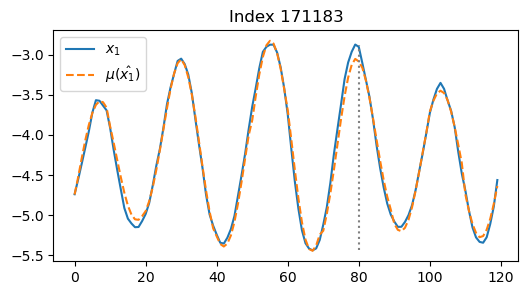

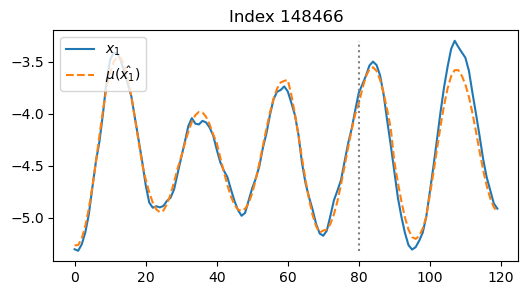

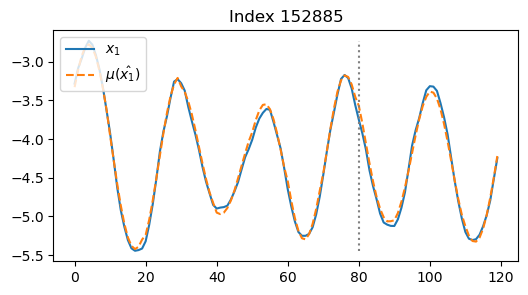

In [9]:
utils_plot.plot_mse_extreme2(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    k=50,
    jsave=159_585,
    datasaved=True, savedir='../../savedata/baselines/tesla')